<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Forbes_The_Global_2000_Companies_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Forbes_2000_Companies_2025.csv', delimiter = ';')
df.head(11)

,Rank,Company,Headquarters,Industry,Sales ($B),Profit ($B),Assets ($B),Market Value ($B)
0,1,JPMorganChase,United States,Banking,285.11,59.36,"4,357.86",677.8
1,2,Berkshire Hathaway,United States,Insurance,371.43,89,"1,153.88","1,145.46"
2,3,ICBC,China,Banking,221.96,50.84,"6,688.6",251.33
3,4,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,Oil & Gas Operations,480.15,104.97,645.03,"1,663.38"
4,5,Amazon,United States,Retail and Wholesale,637.96,59.25,624.89,"2,005.64"
5,6,Bank of America,United States,Banking,196.53,27.85,"3,349.42",300.06
6,7,China Construction Bank,China,Banking,196.71,46.64,"5,558.26",219.81
7,8,Agricultural Bank of China,China,Banking,198.02,39.2,"5,923.64",212.51
8,9,Alphabet,United States,IT Software & Services,359.31,111,475.37,"1,973.64"
9,9,Microsoft,United States,IT Software & Services,261.80,92.75,533.9,"2,913.01"


In [ ]:
df.tail(11)

,Rank,Company,Headquarters,Industry,Sales ($B),Profit ($B),Assets ($B),Market Value ($B)
1989,1989,KakaoBank,South Korea,Banking,2.150,0.3227,42.66,7.27
1990,1991,Allegion,Ireland,Consumer Durables,3.820,0.6219,4.56,11.76
1991,1992,Hisense Kelon Electrical Holdings,China,Consumer Durables,12.830,0.4652,9.55,4.22
1992,1992,Jiangxi Zhengbang Technology,China,"Food, Drink & Tobacco",0.984,1.2,2.68,3.52
1993,1992,Ogaki Kyoritsu Bank,Japan,Banking,0.523,0.0702,42.85,0.647
1994,1995,Tokyo Kiraboshi Financial Group,Japan,Banking,0.781,0.1834,42.84,1.14
1995,1996,Dino Polska,Poland,Food Markets,7.360,0.3781,3.16,13.84
1996,1997,China Aviation Oil,Singapore,Trading Companies,15.520,0.0784,1.99,0.559
1997,1998,Jet2,United Kingdom,Business Services & Supplies,8.790,0.6288,7.95,3.93
1998,1998,Keiyo Bank,Japan,Banking,0.474,0.0927,42.56,0.679


In [ ]:
df.shape

(2000, 8)

In [ ]:
df.columns

Index(['Rank', 'Company', 'Headquarters', 'Industry', 'Sales ($B)',
       'Profit ($B)', 'Assets ($B)', 'Market Value ($B)'],
      dtype='object')

In [ ]:
df.dtypes

,0
Rank,int64
Company,object
Headquarters,object
Industry,object
Sales ($B),float64
Profit ($B),object
Assets ($B),object
Market Value ($B),object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               2000 non-null   int64  
 1   Company            2000 non-null   object 
 2   Headquarters       2000 non-null   object 
 3   Industry           2000 non-null   object 
 4   Sales ($B)         2000 non-null   float64
 5   Profit ($B)        2000 non-null   object 
 6   Assets ($B)        2000 non-null   object 
 7   Market Value ($B)  2000 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 125.1+ KB


In [ ]:
df.describe(include = 'all')

,Rank,Company,Headquarters,Industry,Sales ($B),Profit ($B),Assets ($B),Market Value ($B)
count,2000.000000,2000,2000,2000,2000.000000,2000,2000,2000
unique,NaN,2000,61,31,NaN,1434,1825,1691
top,NaN,Associated Banc-Corp,United States,Banking,NaN,1.08,20.89,19.99
freq,NaN,1,612,326,NaN,13,3,5
mean,1000.331000,NaN,NaN,NaN,26.441630,NaN,NaN,NaN
std,577.430053,NaN,NaN,NaN,47.928105,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,-21.470000,NaN,NaN,NaN
25%,500.750000,NaN,NaN,NaN,6.147500,NaN,NaN,NaN
50%,1000.500000,NaN,NaN,NaN,12.950000,NaN,NaN,NaN
75%,1500.250000,NaN,NaN,NaN,25.707500,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Rank,0
Company,0
Headquarters,0
Industry,0
Sales ($B),0
Profit ($B),0
Assets ($B),0
Market Value ($B),0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Hanlding Outliers

In [ ]:
df['Assets ($B)'] = df['Assets ($B)'].str.replace(',', '').astype(float)

Q1 = df['Assets ($B)'].quantile(0.25)
Q3 = df['Assets ($B)'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['Assets ($B)'] >= lower_bound) & (df['Assets ($B)'] <= upper_bound)].copy()

print('Before removing outliers:', len(df))
print('After removing outliers:', len(df_outliers))

Before removing outliers: 2000
After removing outliers: 1763


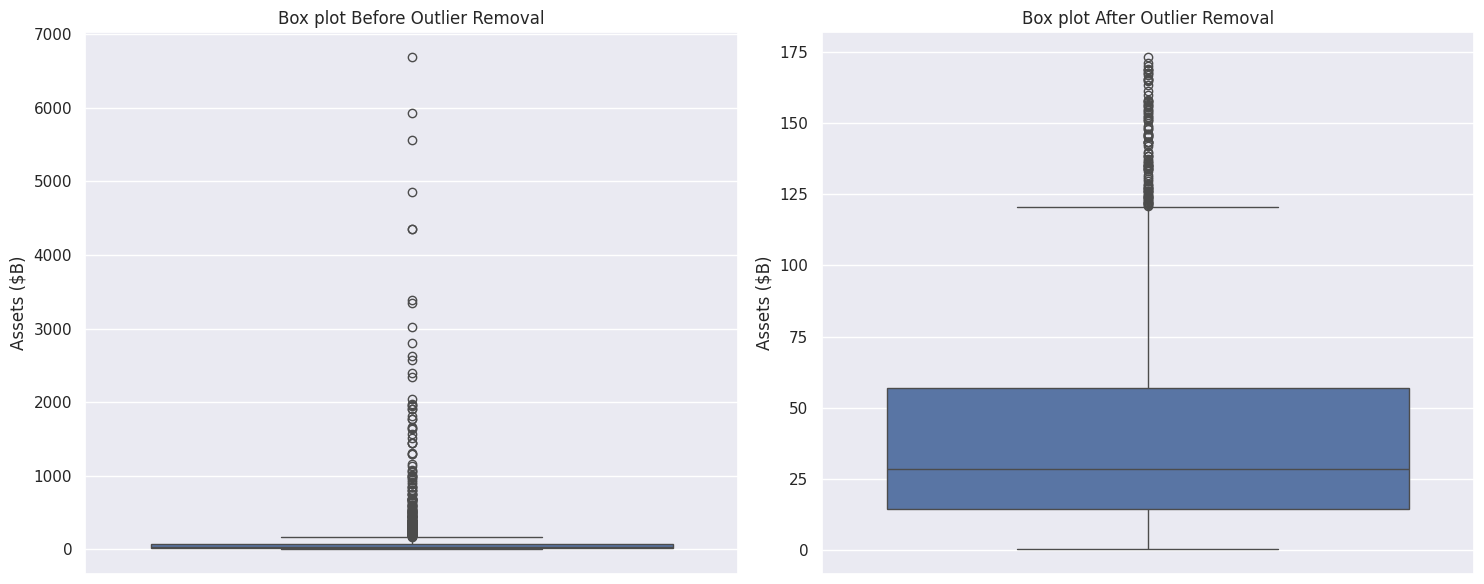

In [ ]:
# Creating a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, y='Assets ($B)', ax=axes[0])
axes[0].set_title('Box plot Before Outlier Removal')
axes[0].set_ylabel('Assets ($B)')

sns.boxplot(data=df_outliers, y='Assets ($B)', ax=axes[1])
axes[1].set_title('Box plot After Outlier Removal')
axes[1].set_ylabel('Assets ($B)')

plt.tight_layout()

plt.show()

# Univariate Analysis

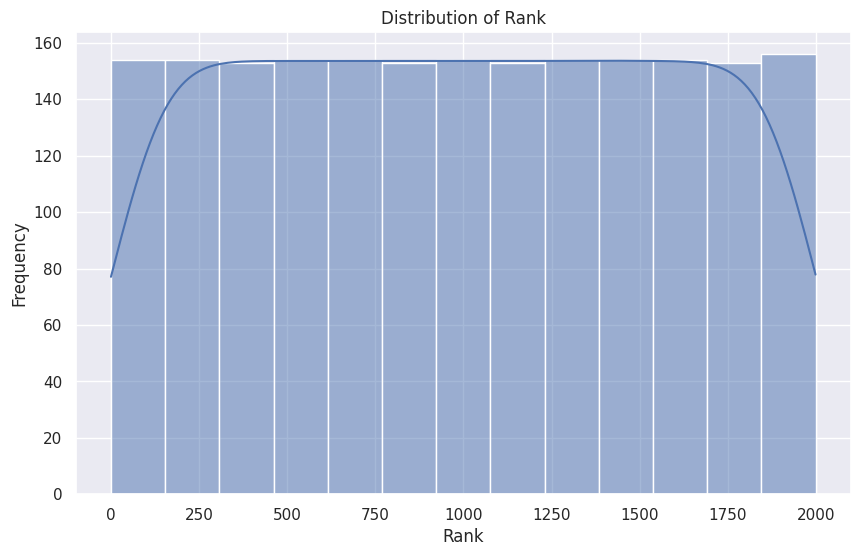

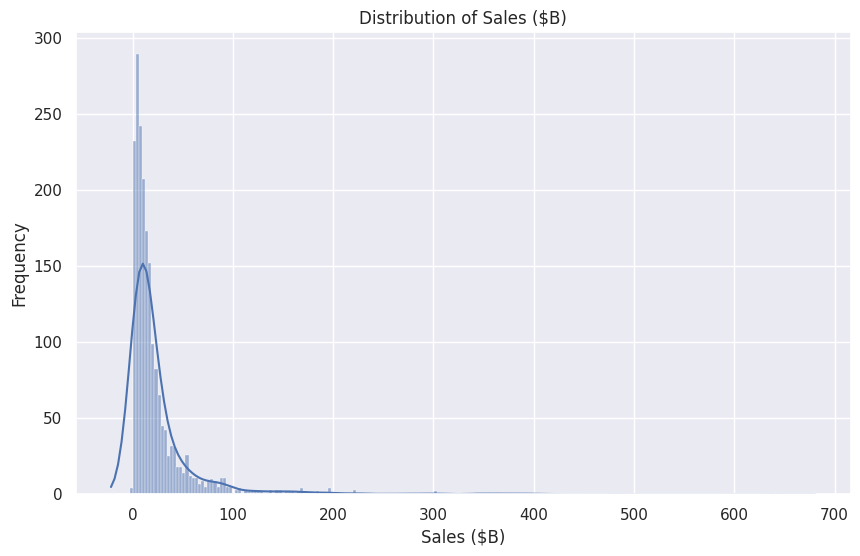

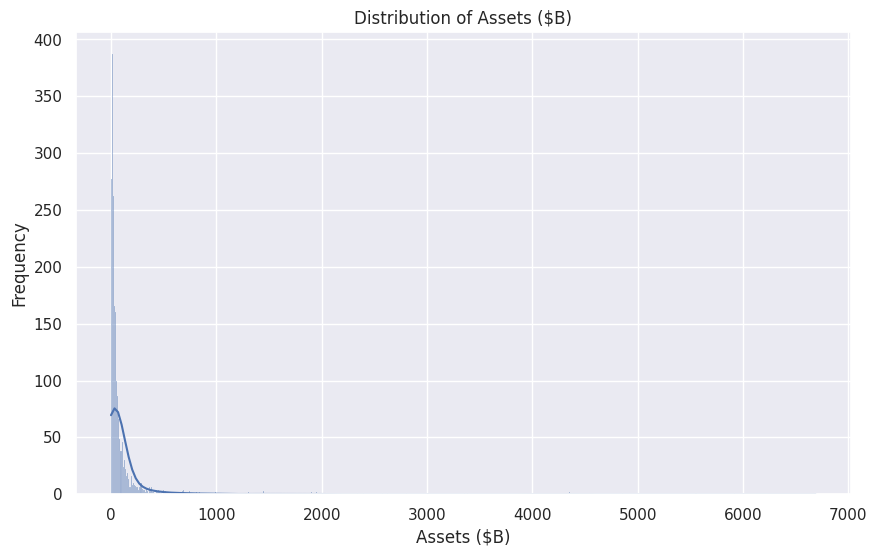

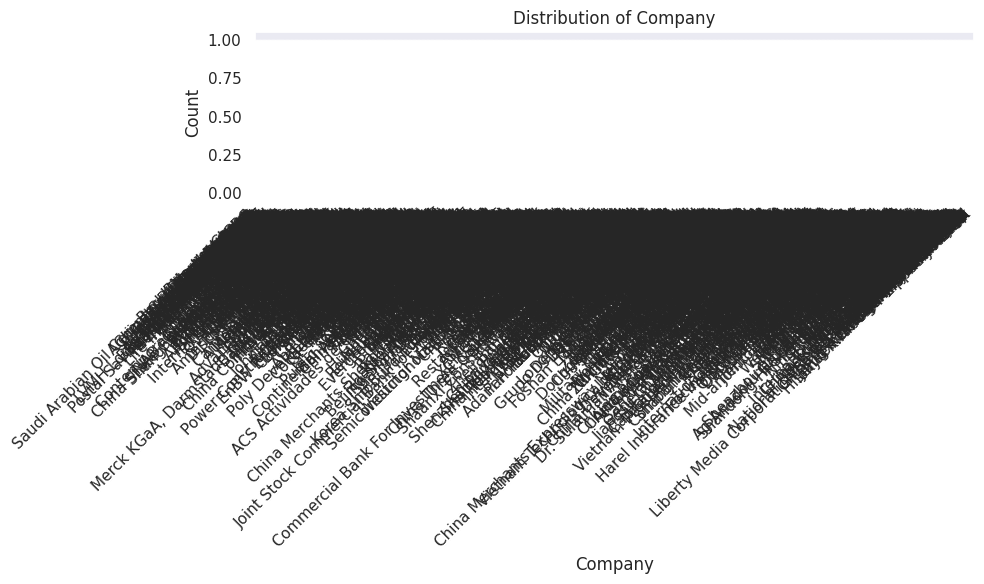

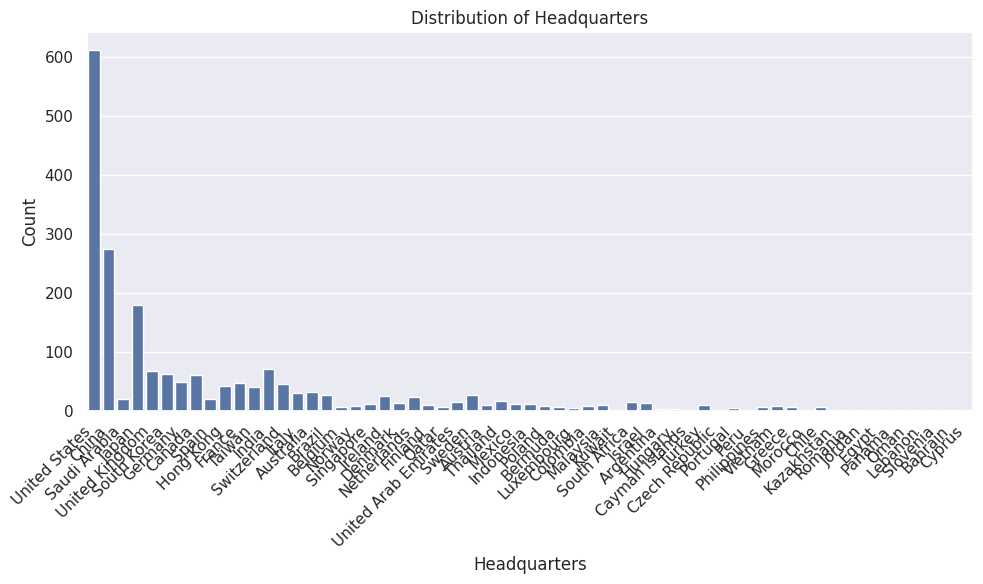

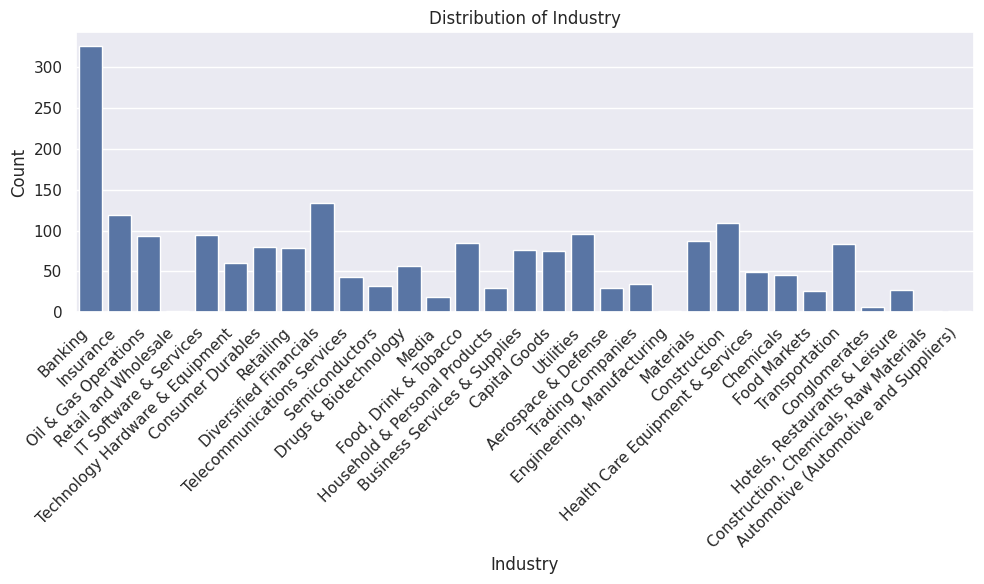

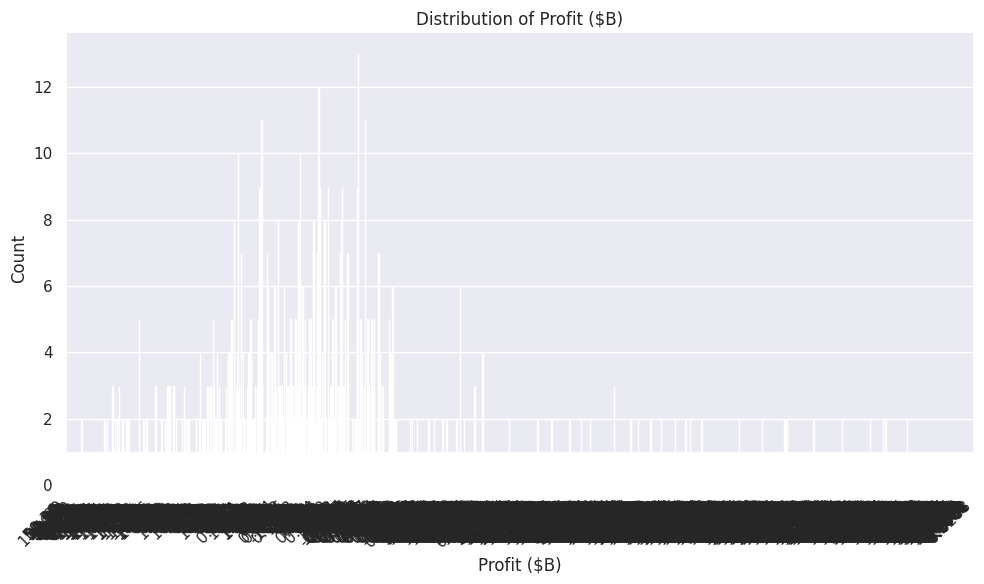

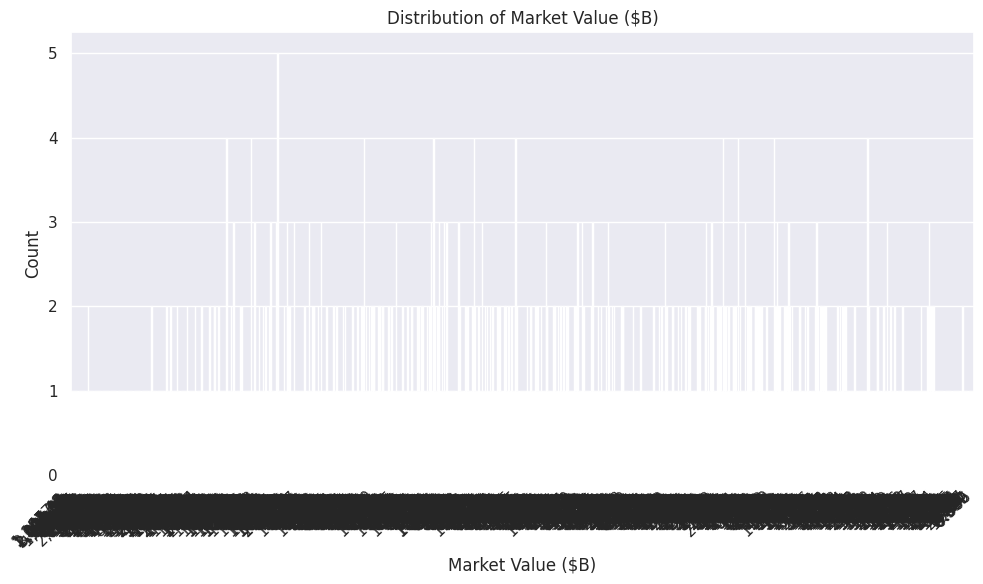

Value counts for Company:
Company
Associated Banc-Corp                        1
Aichi Financial Group                       1
LG Innotek Co.,                             1
Banco Davivienda                            1
NOV                                         1
                                           ..
Amazon                                      1
Saudi Arabian Oil Company (Saudi Aramco)    1
ICBC                                        1
Berkshire Hathaway                          1
JPMorganChase                               1
Name: count, Length: 2000, dtype: int64

Value counts for Headquarters:
Headquarters
United States     612
China             275
Japan             180
India              70
United Kingdom     68
                 ... 
Oman                1
Lebanon             1
Slovenia            1
Bahrain             1
Cyprus              1
Name: count, Length: 61, dtype: int64

Value counts for Industry:
Industry
Banking                                   326
Diversified 

In [ ]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

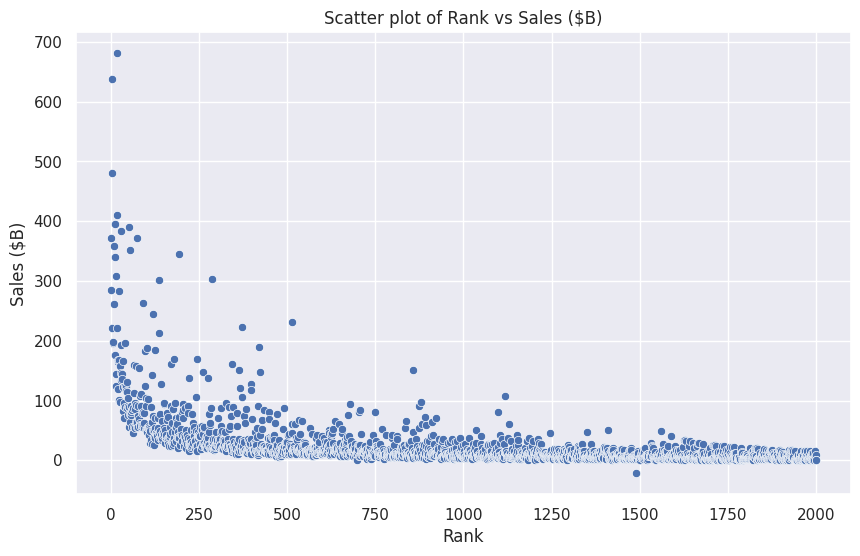

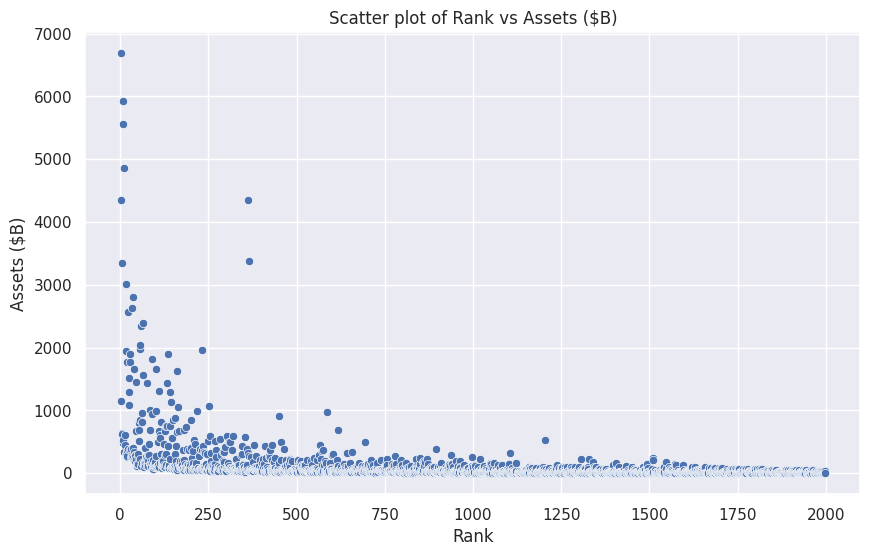

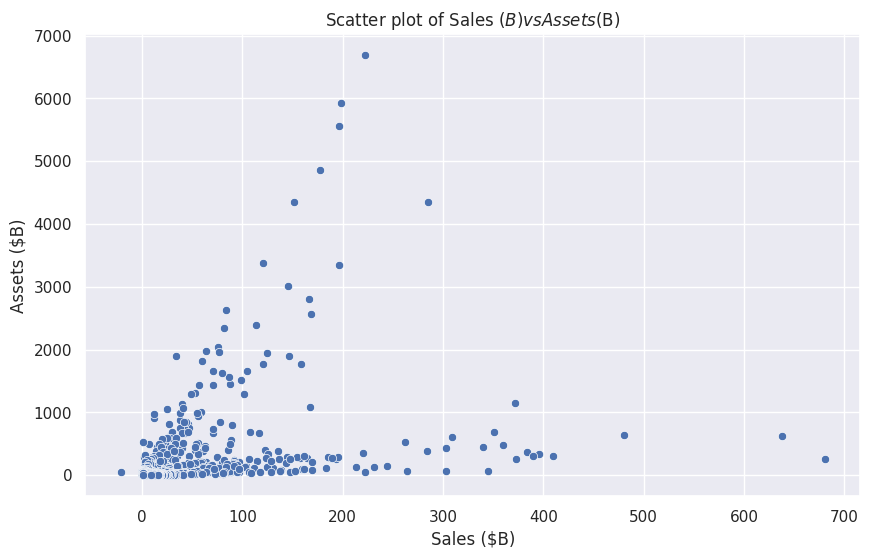

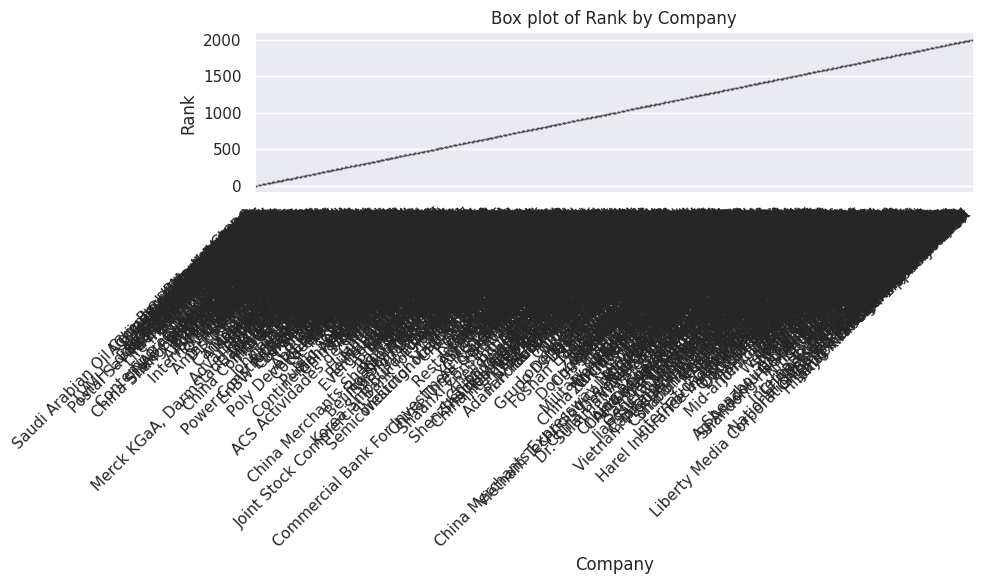

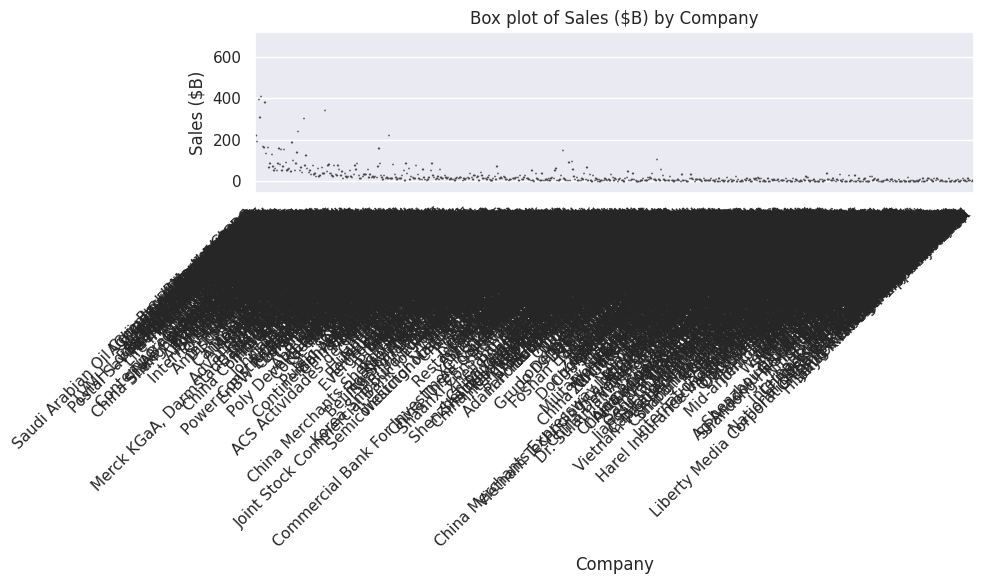

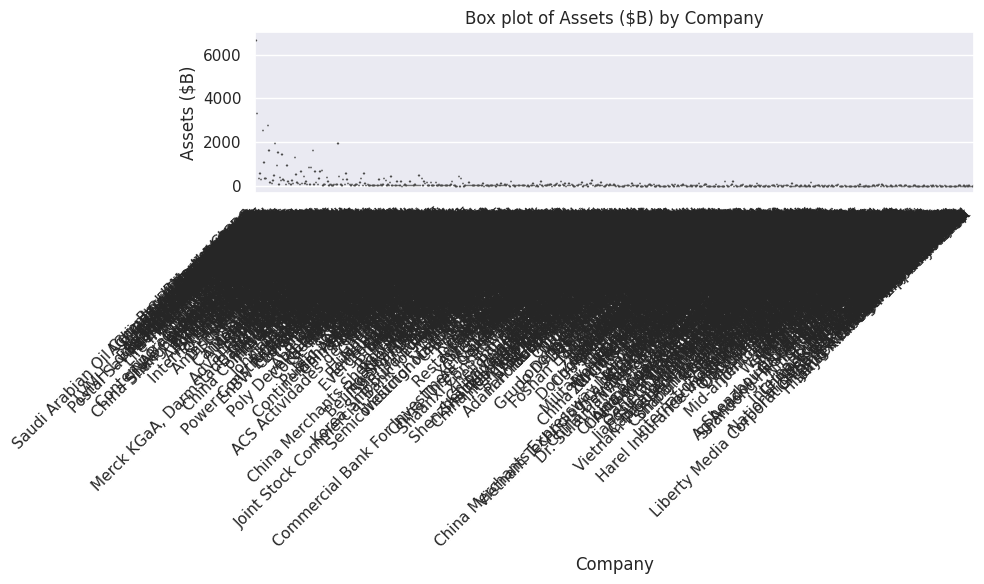

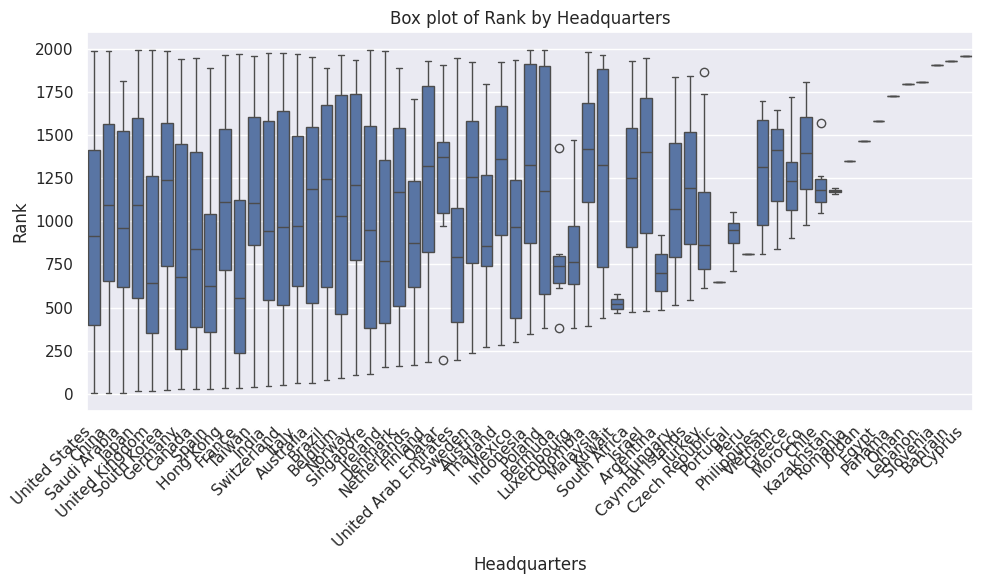

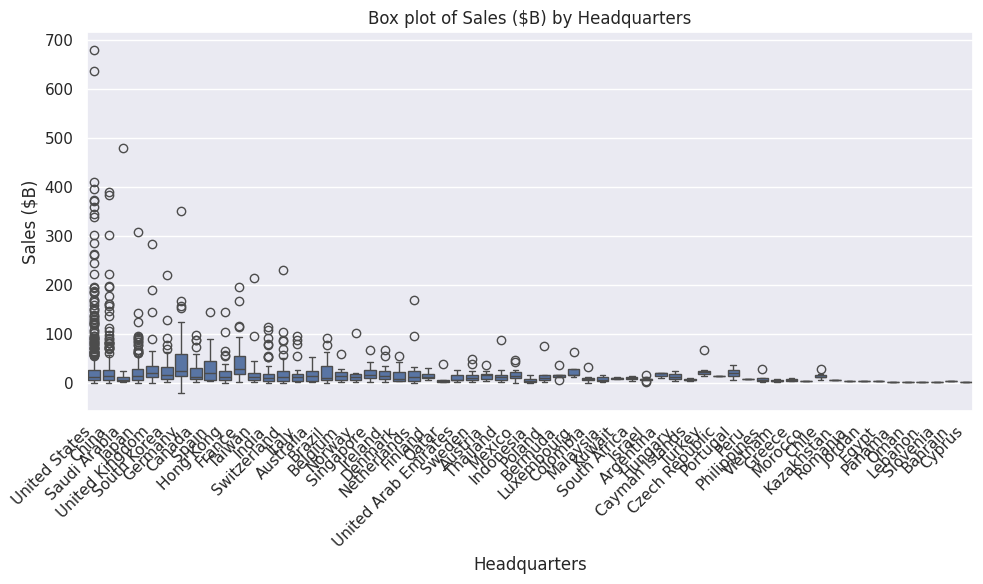

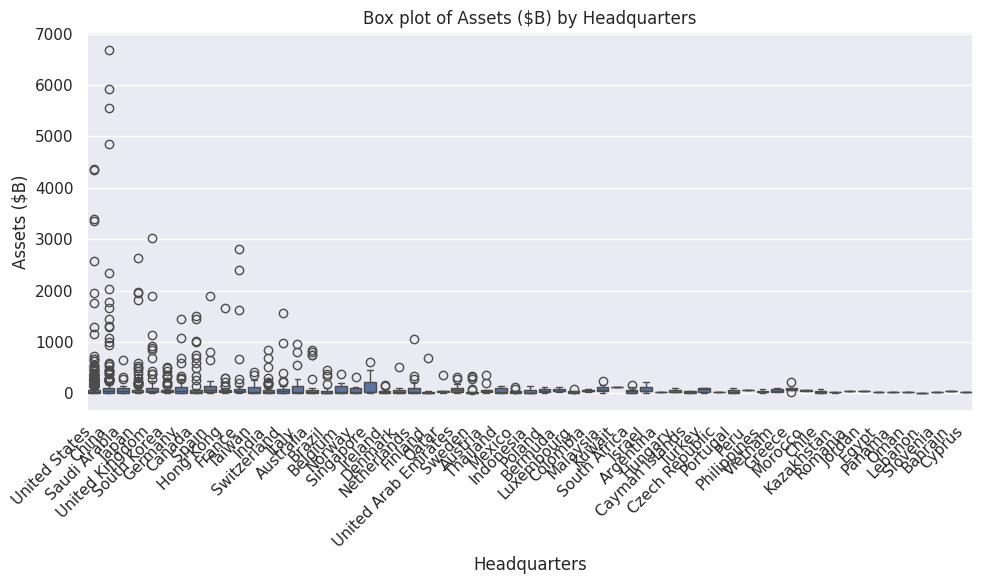

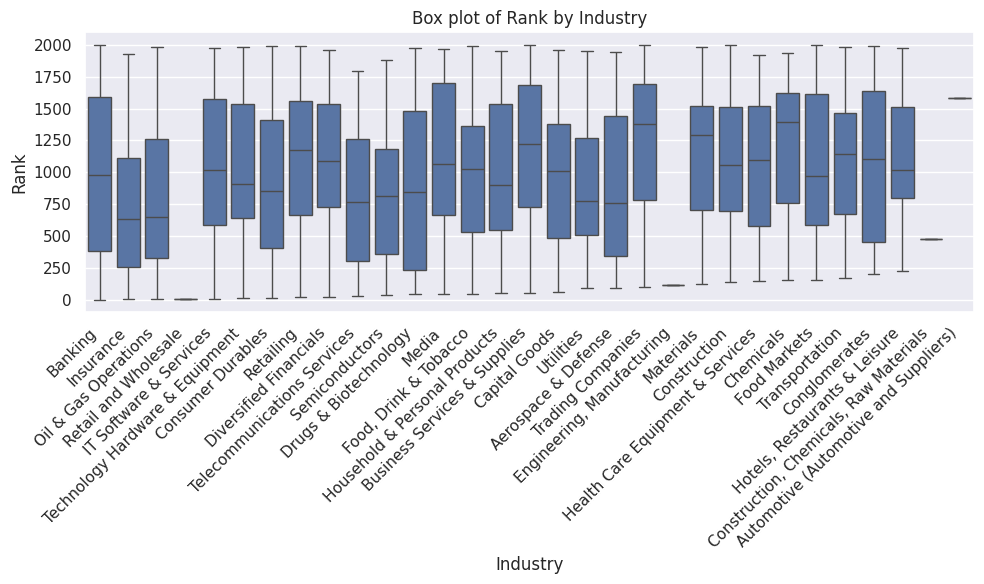

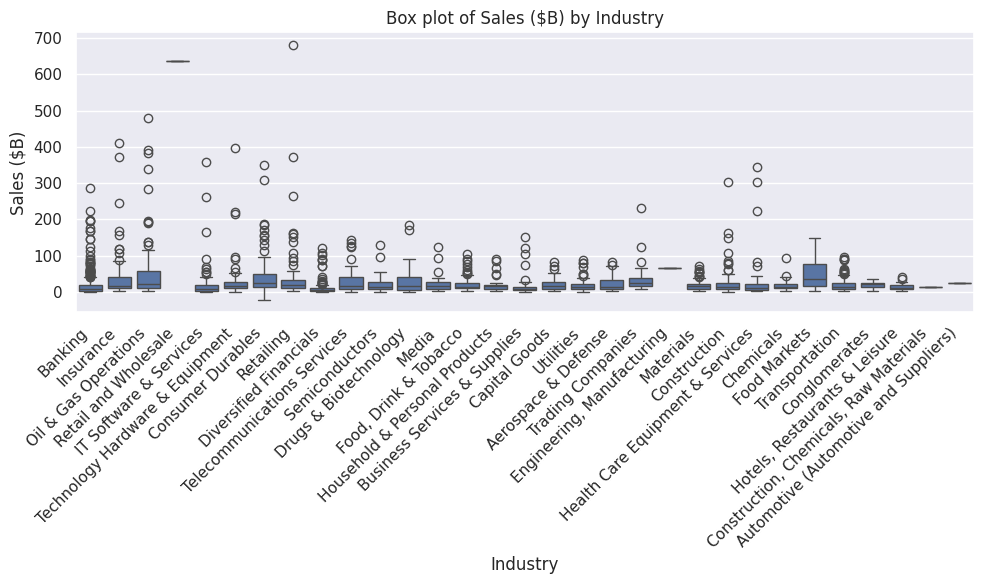

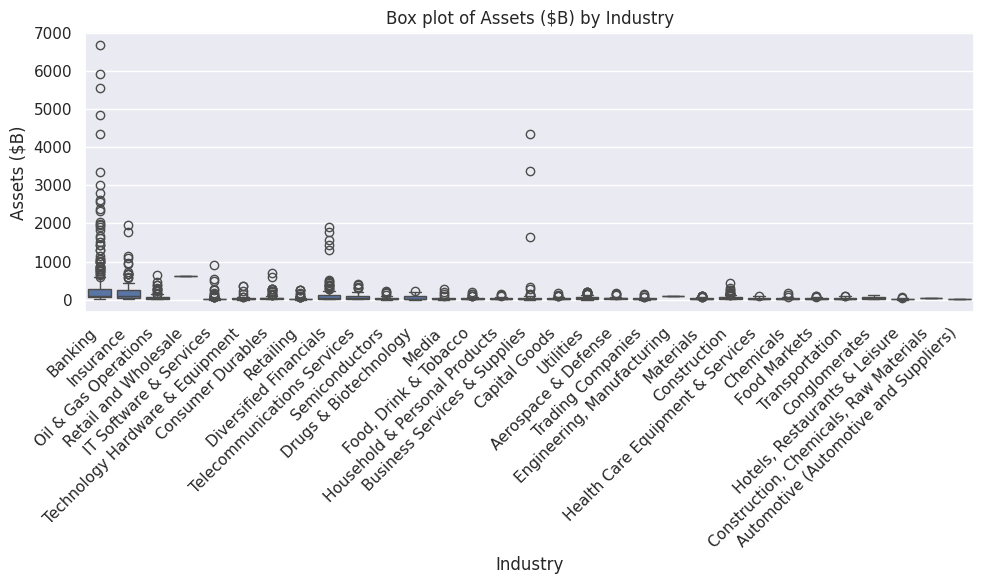

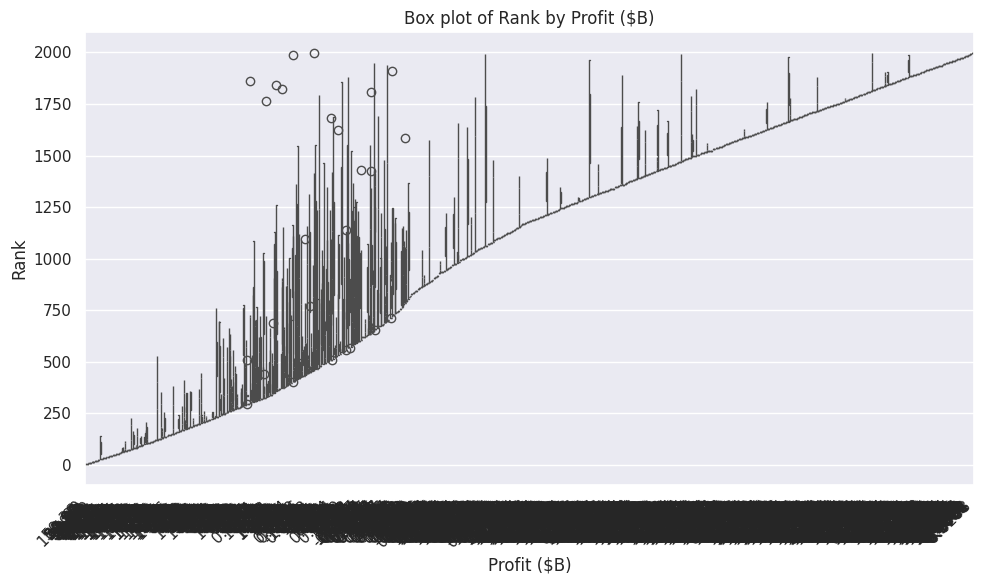

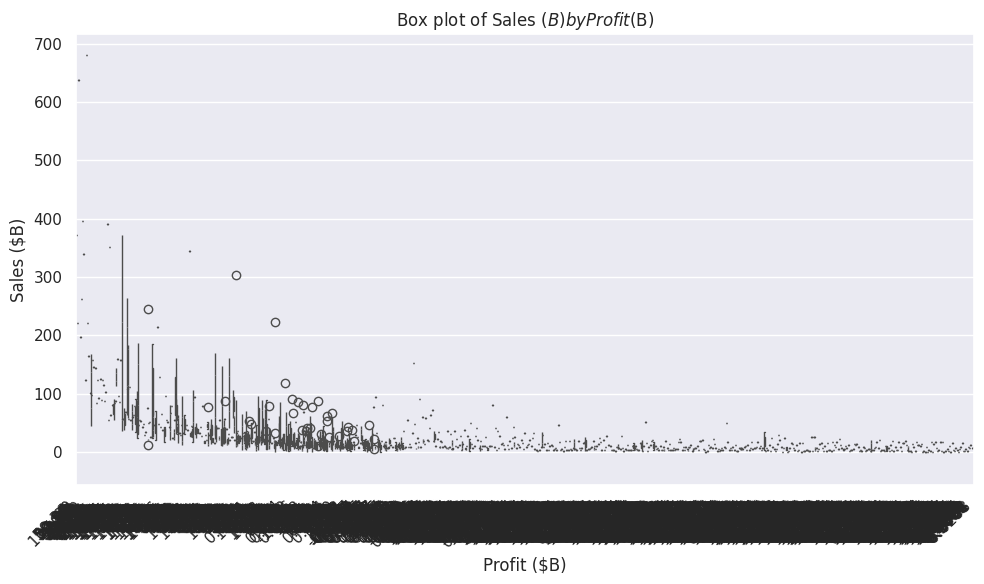

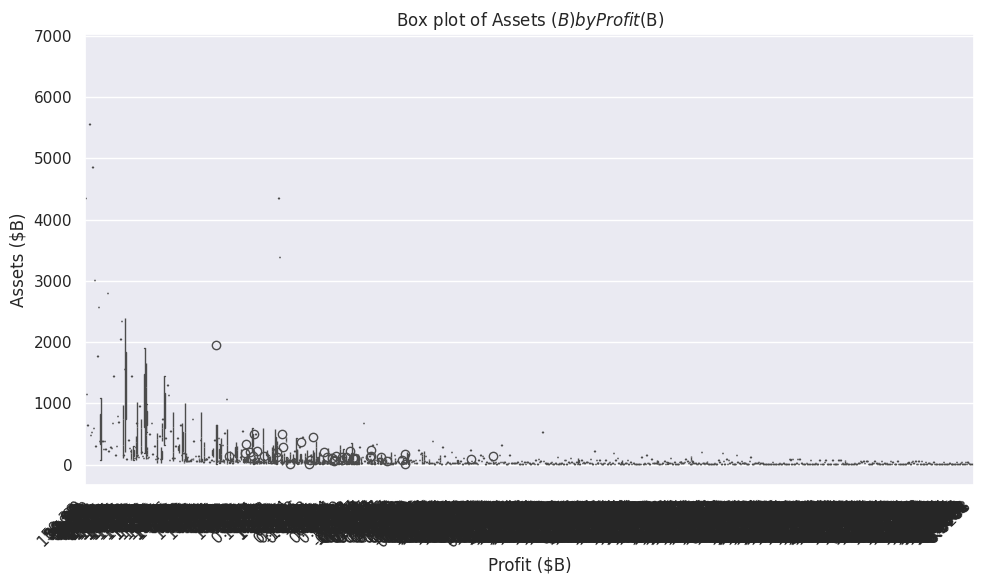

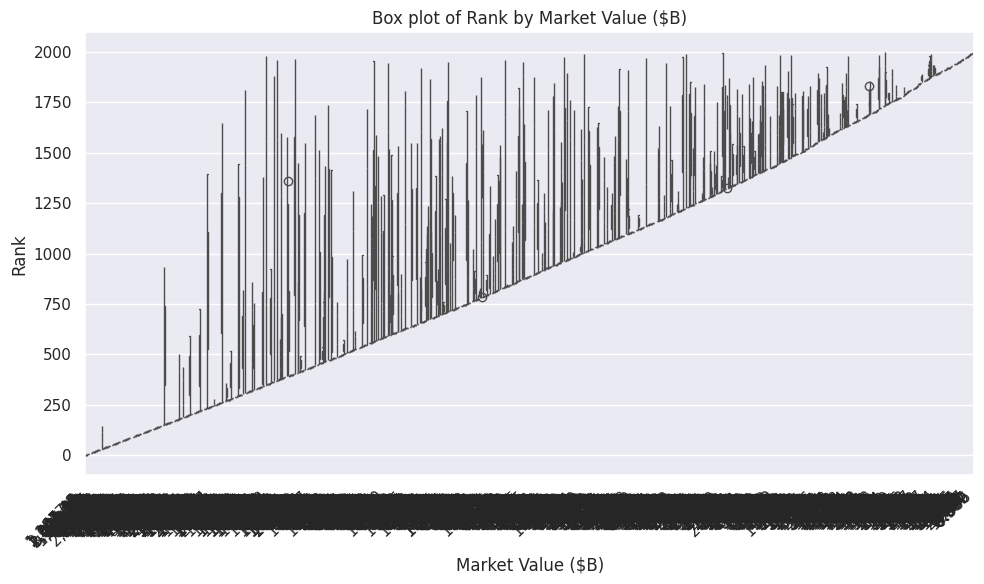

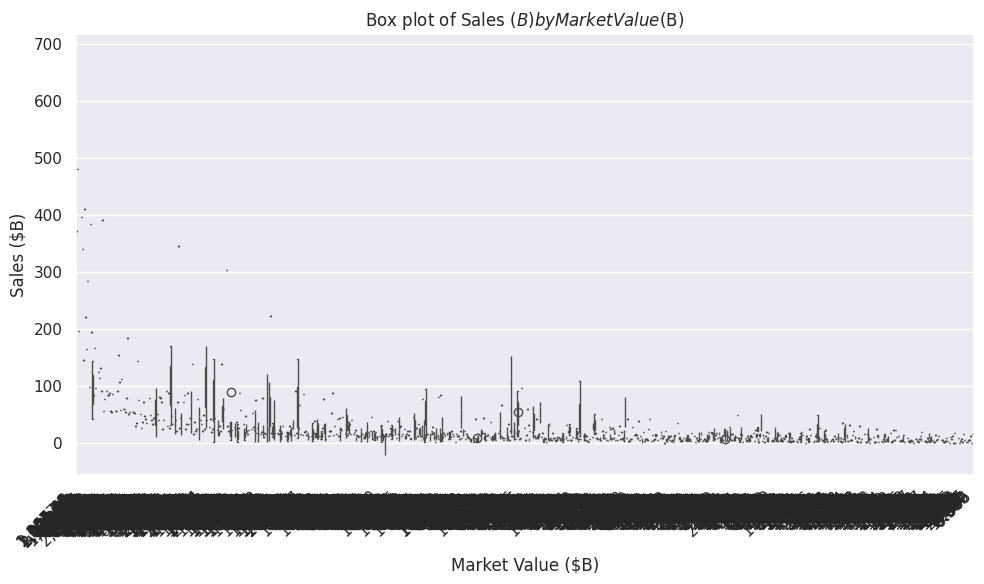

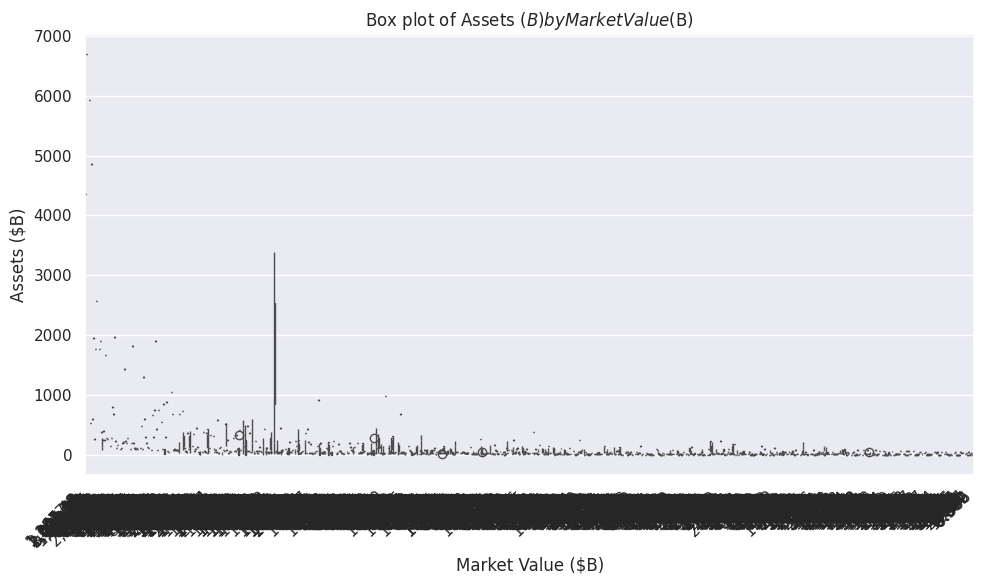

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

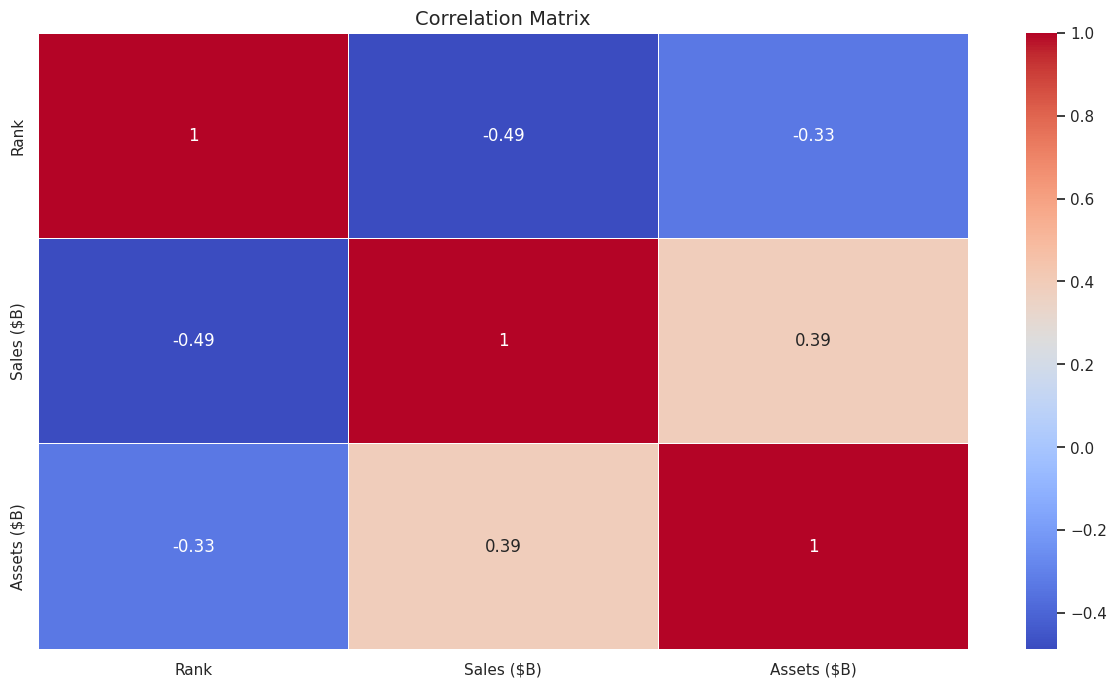

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Conclusion

1. The dataset contains information on 2000 global companies across various industries and headquarters locations.
2. Initial data exploration revealed that several columns, specifically 'Profit B', 'Assets B', 'Assets B', and 'Market Value B', were initially read as object types due to the presence of commas and likely other non-numeric characters, which required data cleaning for numerical analysis. * Outlier detection and removal for the 'Assets B', were initially read as object types due to the presence of commas and likely other non-numeric characters, which required data cleaning for numerical analysis. * Outlier detection and removal for the 'Assets B' column using the IQR method showed a significant number of outliers, indicating a skewed distribution with a few companies having exceptionally high asset values compared to the majority. Removing these outliers provided a clearer view of the distribution for the bulk of the companies.
3. Univariate analysis highlighted the distribution of individual features. For numerical columns like 'Sales B' and 'Assets $B' and 'Assets B', the distributions were heavily skewed, with a large concentration of companies having lower values and fewer companies with very high values. Categorical features like 'Headquarters' and 'Industry' showed that the United States and the Banking industry dominate the dataset in terms of the number of companies.
4. Bivariate analysis and the correlation matrix indicated some relationships between the numerical variables. 'Sales B' and 'Assets B' and 'Assets B' show a moderate positive correlation, suggesting that companies with higher sales tend to have higher assets. The 'Rank' column shows negative correlations with 'Sales B' and 'Assets B' and 'Assets B', which is expected as lower ranks correspond to higher values in these financial metrics.

# Thank you